## Feature Selection: Feature Importance & RFE Ensemble

In this notebook, we compare and combine two advanced feature selection methods to select the most robust features for predicting house prices in Austin, TX:
1. **Random Forest Feature Importance**
2. **Recursive Feature Elimination (RFE) with Ridge/Linear Regression**

By intersecting the results of both, we obtain a consensus feature subset that is robust to both linear and non-linear models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

### 1. Load Data & Prepare X, y

In [2]:
df = pd.read_csv('../data/processed/processed_housing_data.csv')

# Exclude non-numeric and target columns
exclude_cols = ['list_price', 'listing_status', 'listing_type', 'city', 'price_per_sqft']
X = df.drop(columns=[c for c in exclude_cols if c in df.columns])
y = df['list_price']

print(f"X shape: {X.shape}, y shape: {y.shape}")
print("Features included for selection:", list(X.columns))

X shape: (2766, 19), y shape: (2766,)
Features included for selection: ['beds', 'baths', 'sqft_living', 'lot_sqft', 'year_built', 'zip_code', 'latitude', 'longitude', 'hoa_fee', 'days_on_market', 'parking_garage', 'stories', 'property_type_LAND', 'property_type_MOBILE', 'property_type_MULTI_FAMILY', 'property_type_SINGLE_FAMILY', 'property_type_TOWNHOMES', 'house_age', 'baths_per_bed']


### 2. Method 1: Random Forest Feature Importance
Random Forest measures how much each feature decreases impurity across all decision trees.

C:\Users\moham\AppData\Local\Temp\ipykernel_1680\1537538353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')


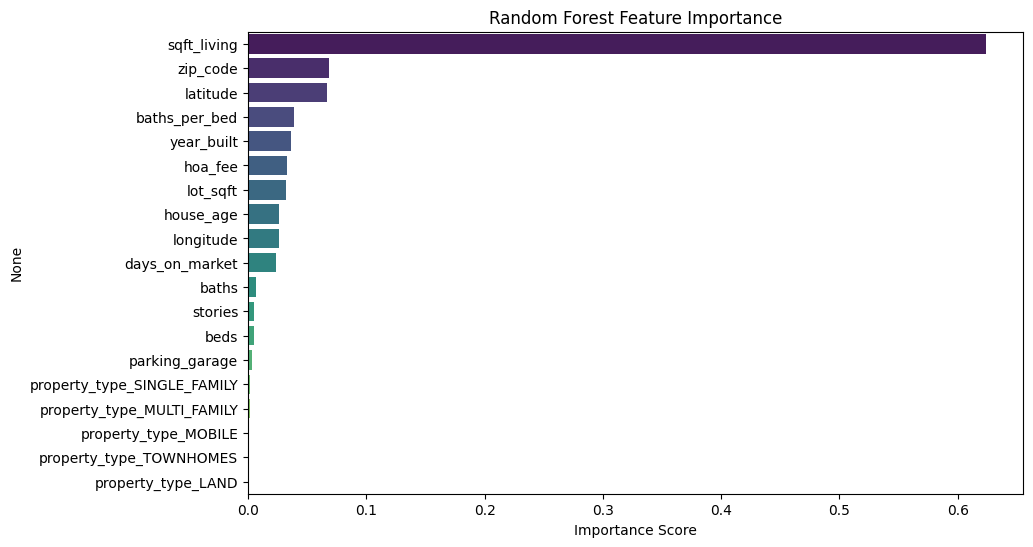

In [3]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.show()

### 3. Method 2: Recursive Feature Elimination (RFE)
RFE fits a model (e.g., Ridge Regression) and recursively removes the weakest features.

In [4]:
# Scale features first as Ridge is sensitive to scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Let's request RFE to select top 8 features
estimator = Ridge(alpha=1.0)
rfe = RFE(estimator, n_features_to_select=8, step=1)
rfe.fit(X_scaled, y)

rfe_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

rfe_ranking

,Feature,Selected,Ranking
0,beds,True,1
1,baths,True,1
2,sqft_living,True,1
4,year_built,True,1
6,latitude,True,1
5,zip_code,True,1
8,hoa_fee,True,1
18,baths_per_bed,True,1
11,stories,False,2
17,house_age,False,3


### 4. Consensus / Ensemble Selection
Let's select the top 8 features from Random Forest and cross-reference them with the RFE selected features.

In [5]:
top_rf_features = list(rf_importances.head(8).index)
top_rfe_features = list(rfe_ranking[rfe_ranking['Selected'] == True]['Feature'])

common_features = set(top_rf_features).intersection(set(top_rfe_features))
union_features = set(top_rf_features).union(set(top_rfe_features))

print("Top 8 RF Features:", top_rf_features)
print("Top 8 RFE Features:", top_rfe_features)
print("--- CONSENSUS RESULTS ---")
print("🔒 Features selected by BOTH (Common):", list(common_features))
print("⭐ Union of features (All candidate features):", list(union_features))

Top 8 RF Features: ['sqft_living', 'zip_code', 'latitude', 'baths_per_bed', 'year_built', 'hoa_fee', 'lot_sqft', 'house_age']
Top 8 RFE Features: ['beds', 'baths', 'sqft_living', 'year_built', 'latitude', 'zip_code', 'hoa_fee', 'baths_per_bed']
--- CONSENSUS RESULTS ---
🔒 Features selected by BOTH (Common): ['sqft_living', 'baths_per_bed', 'latitude', 'year_built', 'hoa_fee', 'zip_code']
⭐ Union of features (All candidate features): ['sqft_living', 'baths', 'baths_per_bed', 'lot_sqft', 'beds', 'latitude', 'year_built', 'hoa_fee', 'zip_code', 'house_age']
